#### Dataset

- Name: Iris Dataset
- Task: Unsupervised Learning - Clustering
- Source: Scikit-Learn Built-in Dataset
- Samples: 150
- Features: 4
- Reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html


<h1> SVD (Singular Value Decomposition)

The core idea of ​​SVD

SVD decomposes a matrix into three smaller matrices:

$X = U \Sigma V^T$


1. U — Left Singular Vectors
U holds information regarding the samples.
Shape:
(samples × samples)

2. Σ — Singular Values
The most important part of SVD.
It is a diagonal matrix:

$\Sigma =
\begin{bmatrix}
\sigma_1 &0&0\\
0&\sigma_2&0\\
0&0&\sigma_3
\end{bmatrix}
$

The values:

$\sigma_1,\sigma_2,...$

represent the amount of information.

The larger the value:
Information

The greater the amount.
3. $Vᵀ$ — Right Singular Vectors
Determines the direction of the features.
In PCA, it plays roughly the same role as:
Principal Components

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from src.svd import SVD

<h3> Step 1: Test on Iris

In [6]:
iris = load_iris()

X = iris.data
y = iris.target

X_scaled = StandardScaler().fit_transform(
    X
)

svd = SVD(
    n_components=2
)

X_svd = svd.fit_transform(
    X_scaled
)

print(
    X_svd.shape
)

print(svd.S)

print(svd.Vt)

print(X_svd.shape)

(150, 2)
[20.92306556 11.7091661 ]
[[-0.52106591  0.26934744 -0.5804131  -0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]
(150, 2)


<h3> Step 2: Compare with NumPy SVD

In [7]:
U, S, Vt = np.linalg.svd(
    X_scaled,
    full_matrices=False
)

print(S[:2])

print(Vt[:2])

[20.92306556 11.7091661 ]
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]]


One of the applications of SVD:

Data reconstruction using fewer components.

In [8]:
X_reconstructed = svd.inverse_transform(
    X_svd
)

In [9]:
mse = np.mean(
    (
        X_scaled -
        X_reconstructed
    )**2
)

print(
    mse
)

0.04186792799998359


<h3> Step 3: Visualization

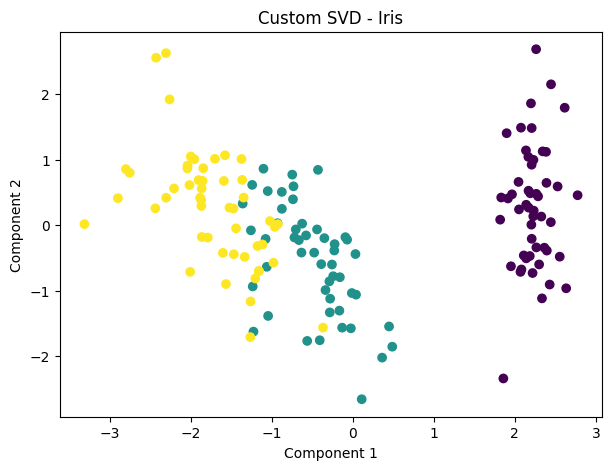

In [10]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_svd[:,0],
    X_svd[:,1],
    c=iris.target
)

plt.title(
    "Custom SVD - Iris"
)

plt.xlabel(
    "Component 1"
)

plt.ylabel(
    "Component 2"
)

plt.show()

#### Comparison of PCA and SVD

| Feature | PCA | SVD |
|-|-|-|
|Main entrance|Covariance Matrix|Data Matrix|
|Solution method|Eigen Decomposition|Matrix Factorization|
|Components|Eigenvectors|Right Singular Vectors|
|Variance|Eigenvalues|Squared Singular Values|
|Application|Dimensionality Reduction|General Matrix Decomposition|

### Singular Value Decomposition (SVD)

#### Overview

Singular Value Decomposition is a matrix factorization technique that decomposes a matrix into three components:

$X = U \Sigma V^T$

SVD is widely used in dimensionality reduction, recommendation systems, and data compression.

---

#### Algorithm

The implementation follows these steps:

1. Compute:

$X^TX$

2. Perform eigenvalue decomposition.

3. Convert eigenvalues into singular values:

$\sigma = \sqrt{\lambda}$

4. Select the largest singular values and corresponding vectors.

5. Project data into the reduced space.

---

#### Implementation

A custom SVD implementation was created with:

- Eigen decomposition
- Singular value calculation
- Component selection
- Data transformation
- Reconstruction

The implementation was tested on the Iris dataset.

---

#### Results

Original dataset:

150 samples
4 features

Reduced representation:


150 samples
2 components

The first two singular values were:

| Component | Singular Value |
|---|---:|
|1|20.92|
|2|11.70|

The reconstructed data achieved:


MSE = 0.0418

showing that most of the important structure was preserved.

---

## Relationship with PCA

SVD and PCA produced equivalent principal directions.

PCA uses eigen decomposition on the covariance matrix, while SVD directly decomposes the original data matrix.

Both methods successfully reduced Iris data from four dimensions to two dimensions while preserving the main structure.